# Práctica 0 - Entropía en Imágenes

Este cuaderno está adaptado a formato de práctica de clase:
- Máximo 20 imágenes por clase para no hacer pesado el proceso.
- Entropía en color y en escala de grises.
- Diagramas de cajas por categoría.
- 3 niveles de modificaciones (pequeña, mediana y grande) en al menos 10 imágenes.
- Informe HTML automático al ejecutar el cuaderno.


In [14]:
%pip install -q scikit-image

Note: you may need to restart the kernel to use updated packages.


In [15]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, color, util

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "images_extracted" / "training_set"
OUT_DIR = BASE_DIR / "output"
GRAF_DIR = OUT_DIR / "graficos"
HIST_DIR = OUT_DIR / "histogramas"
MOD_DIR = OUT_DIR / "modificaciones"
REP_DIR = OUT_DIR / "reportes"

for p in [
    GRAF_DIR,
    HIST_DIR,
    MOD_DIR / "originales",
    MOD_DIR / "pequenas",
    MOD_DIR / "medianas",
    MOD_DIR / "grandes",
    REP_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

MAX_PER_CLASS = 20
print(f"Dataset: {DATA_DIR}")
print(f"Límite por clase: {MAX_PER_CLASS}")

Dataset: /home/jordyr/Scikit-Image-y-Entrop-a-en-Im-genes/images_extracted/training_set
Límite por clase: 20


## ¿Qué es la entropía?

La entropía mide qué tan variada o desordenada es la información de una imagen.
- En escala de grises: se calcula usando la distribución de intensidades de 0 a 255.
- En color: se calcula por canal (R, G, B) y se promedia.

Más entropía significa más detalle y variación; menos entropía significa imagen más uniforme.


In [16]:
def entropy_u8(arr_u8):
    hist, _ = np.histogram(arr_u8.ravel(), bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    return float(-(hist * np.log2(hist)).sum())

def gray_u8(img):
    if img.ndim == 2:
        return util.img_as_ubyte(img)
    return util.img_as_ubyte(color.rgb2gray(img[..., :3]))

def color_entropy(img):
    if img.ndim == 2:
        g = gray_u8(img)
        return entropy_u8(g)
    rgb = util.img_as_ubyte(img[..., :3])
    return float(np.mean([entropy_u8(rgb[..., 0]), entropy_u8(rgb[..., 1]), entropy_u8(rgb[..., 2])]))

def save_hist_panel(img, img_path, out_file):
    rgb = util.img_as_ubyte(img[..., :3]) if img.ndim == 3 else None
    g = gray_u8(img)
    fig, ax = plt.subplots(1, 3, figsize=(10, 3))
    ax[0].imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax[0].set_title(img_path.name)
    ax[0].axis('off')
    ax[1].hist(g.ravel(), bins=256, color='black', alpha=0.85)
    ax[1].set_title('Histograma gris')
    if rgb is not None:
        for i, c in enumerate(['r', 'g', 'b']):
            ax[2].hist(rgb[..., i].ravel(), bins=256, color=c, alpha=0.35)
    else:
        ax[2].hist(g.ravel(), bins=256, color='gray', alpha=0.8)
    ax[2].set_title('Histograma color')
    plt.tight_layout()
    fig.savefig(out_file, dpi=120)
    plt.close(fig)

In [17]:
records = []
valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])

for cdir in class_dirs:
    files = sorted([p for p in cdir.iterdir() if p.suffix.lower() in valid_ext])[:MAX_PER_CLASS]
    for i, f in enumerate(files, start=1):
        img = io.imread(f)
        eg = entropy_u8(gray_u8(img))
        ec = color_entropy(img)
        hist_name = f"{cdir.name}_{i:02d}_{f.stem}.png"
        hist_path = HIST_DIR / hist_name
        save_hist_panel(img, f, hist_path)
        records.append({
            'clase': cdir.name,
            'ruta': str(f.relative_to(BASE_DIR)),
            'nombre': f.name,
            'entropia_gris': eg,
            'entropia_color': ec,
            'hist_file': hist_name
        })

df = pd.DataFrame(records)
print(f"Clases encontradas: {len(class_dirs)}")
print(f"Imágenes procesadas: {len(df)}")
df.head(3)

Clases encontradas: 10
Imágenes procesadas: 200


,clase,ruta,nombre,entropia_gris,entropia_color,hist_file
0,beaches,images_extracted/training_set/beaches/110.jpg,110.jpg,7.312193,7.305171,beaches_01_110.png
1,beaches,images_extracted/training_set/beaches/111.jpg,111.jpg,7.325231,7.379769,beaches_02_111.png
2,beaches,images_extracted/training_set/beaches/112.jpg,112.jpg,7.456642,7.463630,beaches_03_112.png


/tmp/ipykernel_238385/3052301678.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['clase'] == c]['entropia_gris'] for c in classes], labels=classes)


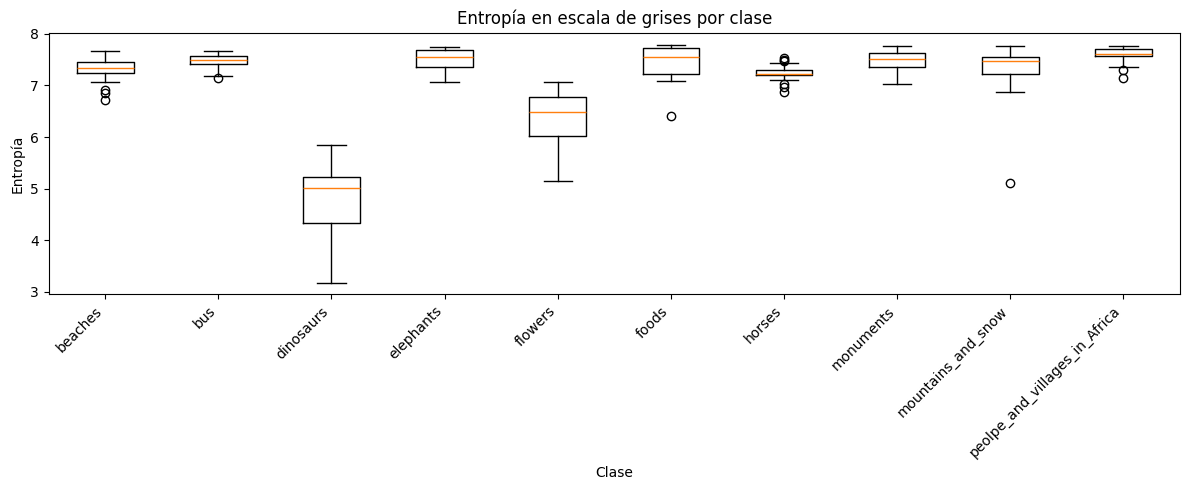

/tmp/ipykernel_238385/3052301678.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[df['clase'] == c]['entropia_color'] for c in classes], labels=classes)


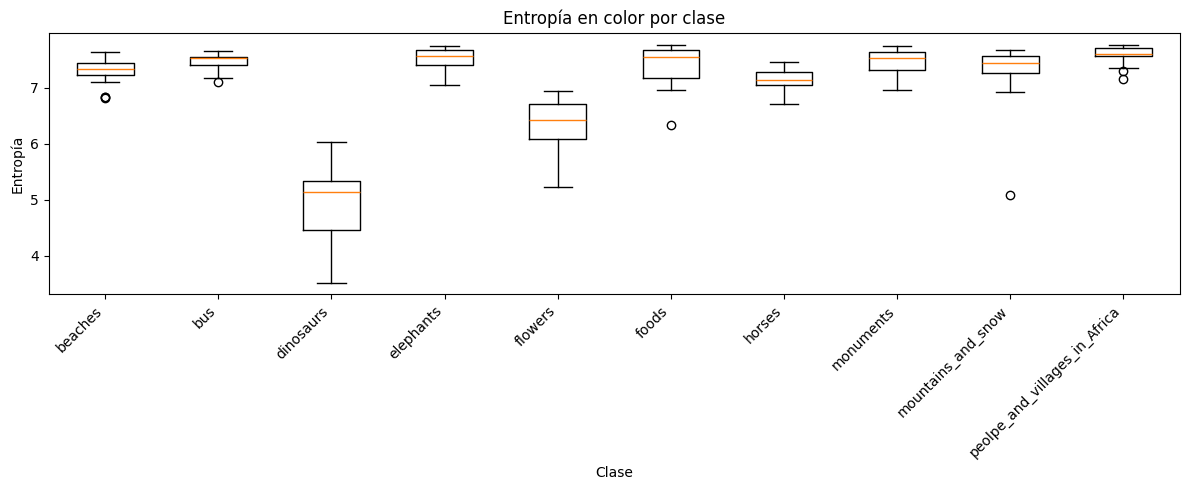

Promedios de entropía por clase (de mayor a menor en color):


,entropia_gris,entropia_color
clase,,
peolpe_and_villages_in_Africa,7.5908,7.5885
elephants,7.5114,7.5282
monuments,7.4701,7.4697
bus,7.4638,7.4674
foods,7.4475,7.4178
beaches,7.2980,7.3060
mountains_and_snow,7.2929,7.3003
horses,7.2376,7.1627
flowers,6.3631,6.3436


Clase con mayor entropía promedio en color: peolpe_and_villages_in_Africa
Esto suele ocurrir cuando hay más textura, objetos y variación de iluminación/colores en la escena.


In [18]:
classes = sorted(df['clase'].unique())

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot([df[df['clase'] == c]['entropia_gris'] for c in classes], labels=classes)
ax.set_title('Entropía en escala de grises por clase')
ax.set_xlabel('Clase')
ax.set_ylabel('Entropía')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
box_gray = GRAF_DIR / 'boxplot_entropia_gris.png'
plt.savefig(box_gray, dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot([df[df['clase'] == c]['entropia_color'] for c in classes], labels=classes)
ax.set_title('Entropía en color por clase')
ax.set_xlabel('Clase')
ax.set_ylabel('Entropía')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
box_color = GRAF_DIR / 'boxplot_entropia_color.png'
plt.savefig(box_color, dpi=140)
plt.show()

resumen = df.groupby('clase')[['entropia_gris', 'entropia_color']].mean().sort_values('entropia_color', ascending=False)
print('Promedios de entropía por clase (de mayor a menor en color):')
display(resumen.round(4))

clase_top = resumen.index[0]
print(f"Clase con mayor entropía promedio en color: {clase_top}")
print('Esto suele ocurrir cuando hay más textura, objetos y variación de iluminación/colores en la escena.')

## Modificaciones (pequeña, mediana y grande)

Se toman al menos 10 imágenes y se aplican 3 niveles de cambio para comparar su entropía.


In [19]:
def mod_pequena(img):
    out = util.img_as_ubyte(img).copy()
    h, w = out.shape[:2]
    y0, x0 = h // 6, w // 6
    hh, ww = max(8, h // 16), max(8, w // 16)
    if out.ndim == 2:
        out[y0:y0+hh, x0:x0+ww] = 255
    else:
        out[y0:y0+hh, x0:x0+ww, :] = [255, 0, 0]
    return out

def mod_mediana(img):
    out = util.img_as_ubyte(img).copy()
    h, w = out.shape[:2]
    y0, x0 = h // 3, w // 3
    hh, ww = max(20, h // 5), max(20, w // 5)
    if out.ndim == 2:
        out[y0:y0+hh, x0:x0+ww] = out[y0:y0+hh, x0:x0+ww] // 3
    else:
        out[y0:y0+hh, x0:x0+ww, :] = out[y0:y0+hh, x0:x0+ww, :] // 3
    return out

def mod_grande(img):
    out = util.img_as_ubyte(img).copy()
    h, w = out.shape[:2]
    if out.ndim == 2:
        out[:, :w//2] = 255 - out[:, :w//2]
    else:
        out[:, :w//2, :] = 255 - out[:, :w//2, :]
    return out

seleccion = df.groupby('clase', as_index=False).head(1).head(10).copy()
niveles = [('pequena', mod_pequena), ('mediana', mod_mediana), ('grande', mod_grande)]
mod_rows = []

for _, row in seleccion.iterrows():
    img_path = BASE_DIR / row['ruta']
    img = io.imread(img_path)
    img_u8 = util.img_as_ubyte(img)
    base_entropy = entropy_u8(gray_u8(img_u8))
    nombre_corto = Path(row['nombre']).stem

    original_file = MOD_DIR / 'originales' / f"{row['clase']}_{nombre_corto}_original.png"
    io.imsave(original_file, img_u8)

    for nivel, fn in niveles:
        img_m = fn(img_u8)
        e_m = entropy_u8(gray_u8(img_m))
        out_file = MOD_DIR / (nivel + 's') / f"{row['clase']}_{nombre_corto}_{nivel}.png"
        io.imsave(out_file, img_m)
        mod_rows.append({
            'imagen': nombre_corto,
            'clase': row['clase'],
            'nivel': nivel,
            'entropia_original_gris': base_entropy,
            'entropia_modificada_gris': e_m,
            'diferencia': e_m - base_entropy,
            'ruta_original_out': str(original_file.relative_to(OUT_DIR)),
            'ruta_modificada_out': str(out_file.relative_to(OUT_DIR))
        })

df_mod = pd.DataFrame(mod_rows)
print(f"Imágenes usadas para modificación: {df_mod['imagen'].nunique()}")
df_mod.head(6)

Imágenes usadas para modificación: 10


,imagen,clase,nivel,entropia_original_gris,entropia_modificada_gris,diferencia,ruta_original_out,ruta_modificada_out
0,110,beaches,pequena,7.312193,7.314864,0.002671,modificaciones/originales/beaches_110_original...,modificaciones/pequenas/beaches_110_pequena.png
1,110,beaches,mediana,7.312193,7.334584,0.022391,modificaciones/originales/beaches_110_original...,modificaciones/medianas/beaches_110_mediana.png
2,110,beaches,grande,7.312193,7.764663,0.452470,modificaciones/originales/beaches_110_original...,modificaciones/grandes/beaches_110_grande.png
3,310,bus,pequena,7.570971,7.570378,-0.000592,modificaciones/originales/bus_310_original.png,modificaciones/pequenas/bus_310_pequena.png
4,310,bus,mediana,7.570971,7.542515,-0.028455,modificaciones/originales/bus_310_original.png,modificaciones/medianas/bus_310_mediana.png
5,310,bus,grande,7.570971,7.857960,0.286989,modificaciones/originales/bus_310_original.png,modificaciones/grandes/bus_310_grande.png


# Visualizamos los cambios promedios en antropia gris

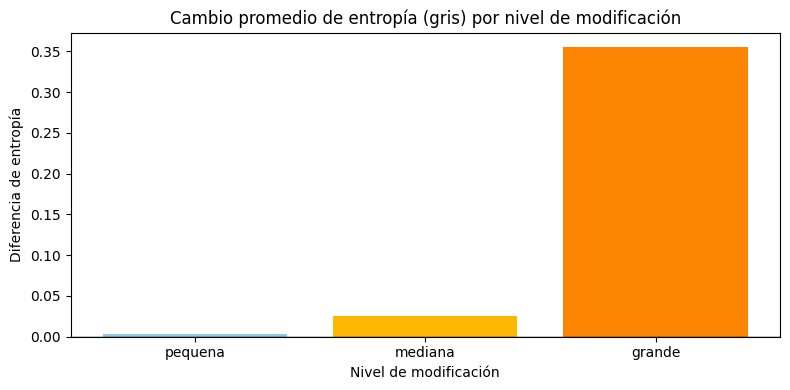

,count,mean,std,min,25%,50%,75%,max
nivel,,,,,,,,
grande,10.0,0.3550,0.2646,0.0140,0.0966,0.3697,0.5943,0.6872
mediana,10.0,0.0255,0.0316,-0.0285,0.0067,0.0220,0.0459,0.0806
pequena,10.0,0.0037,0.0085,-0.0043,-0.0013,0.0010,0.0049,0.0253


In [20]:
prom_nivel = df_mod.groupby('nivel')['diferencia'].mean().reindex(['pequena', 'mediana', 'grande'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(prom_nivel.index, prom_nivel.values, color=['#8ecae6', '#ffb703', '#fb8500'])
ax.set_title('Cambio promedio de entropía (gris) por nivel de modificación')
ax.set_xlabel('Nivel de modificación')
ax.set_ylabel('Diferencia de entropía')
ax.axhline(0, color='black', linewidth=1)
plt.tight_layout()
bars_file = GRAF_DIR / 'barras_cambio_entropia_modificaciones.png'
plt.savefig(bars_file, dpi=140)
plt.show()

display(df_mod.groupby('nivel')['diferencia'].describe().round(4))

# Realizamos los cambios en todas las clases (pequenos, medianos, grandes)

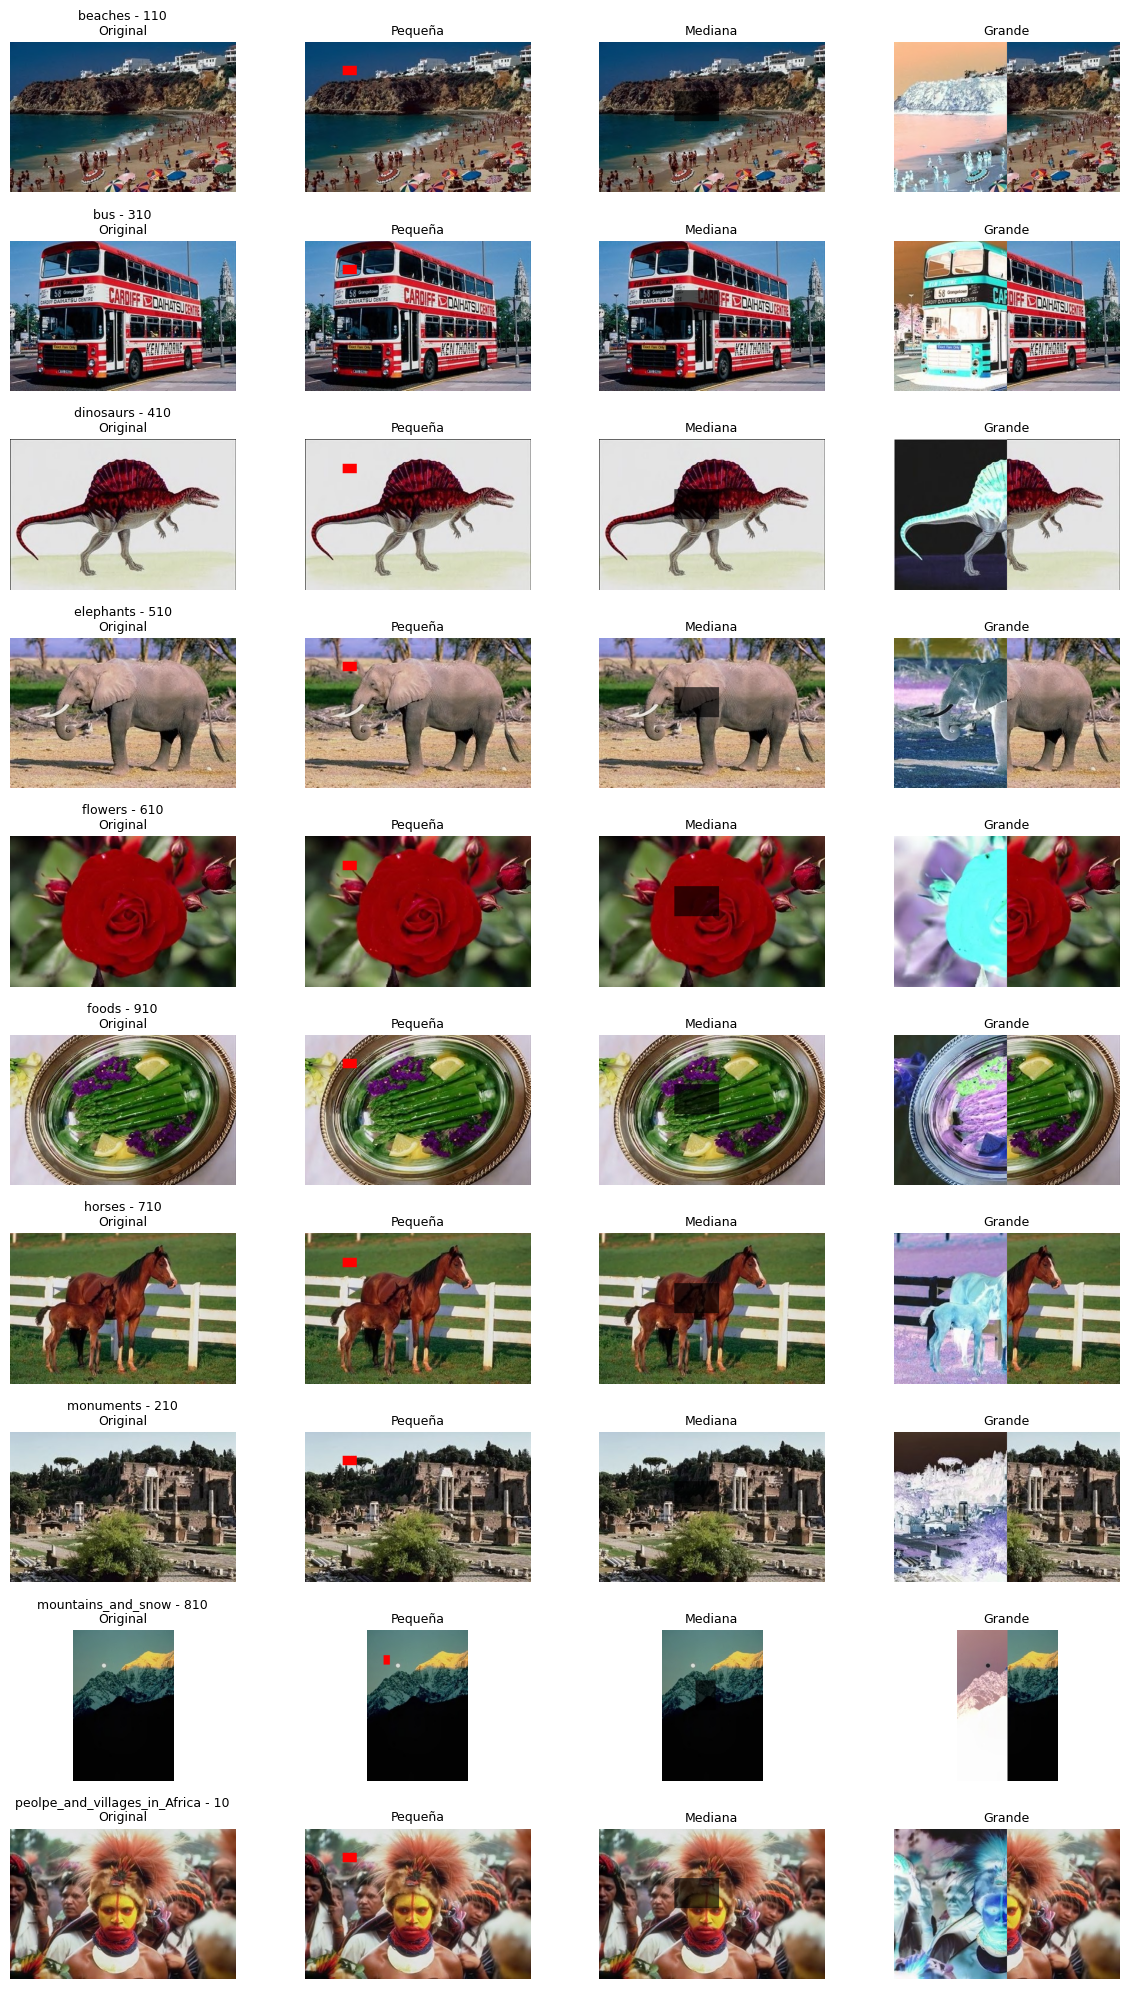

,clase,imagen,original,pequena,mediana,grande
0,beaches,110,modificaciones/originales/beaches_110_original...,modificaciones/pequenas/beaches_110_pequena.png,modificaciones/medianas/beaches_110_mediana.png,modificaciones/grandes/beaches_110_grande.png
1,bus,310,modificaciones/originales/bus_310_original.png,modificaciones/pequenas/bus_310_pequena.png,modificaciones/medianas/bus_310_mediana.png,modificaciones/grandes/bus_310_grande.png
2,dinosaurs,410,modificaciones/originales/dinosaurs_410_origin...,modificaciones/pequenas/dinosaurs_410_pequena.png,modificaciones/medianas/dinosaurs_410_mediana.png,modificaciones/grandes/dinosaurs_410_grande.png
3,elephants,510,modificaciones/originales/elephants_510_origin...,modificaciones/pequenas/elephants_510_pequena.png,modificaciones/medianas/elephants_510_mediana.png,modificaciones/grandes/elephants_510_grande.png
4,flowers,610,modificaciones/originales/flowers_610_original...,modificaciones/pequenas/flowers_610_pequena.png,modificaciones/medianas/flowers_610_mediana.png,modificaciones/grandes/flowers_610_grande.png
5,foods,910,modificaciones/originales/foods_910_original.png,modificaciones/pequenas/foods_910_pequena.png,modificaciones/medianas/foods_910_mediana.png,modificaciones/grandes/foods_910_grande.png
6,horses,710,modificaciones/originales/horses_710_original.png,modificaciones/pequenas/horses_710_pequena.png,modificaciones/medianas/horses_710_mediana.png,modificaciones/grandes/horses_710_grande.png
7,monuments,210,modificaciones/originales/monuments_210_origin...,modificaciones/pequenas/monuments_210_pequena.png,modificaciones/medianas/monuments_210_mediana.png,modificaciones/grandes/monuments_210_grande.png
8,mountains_and_snow,810,modificaciones/originales/mountains_and_snow_8...,modificaciones/pequenas/mountains_and_snow_810...,modificaciones/medianas/mountains_and_snow_810...,modificaciones/grandes/mountains_and_snow_810_...
9,peolpe_and_villages_in_Africa,10,modificaciones/originales/peolpe_and_villages_...,modificaciones/pequenas/peolpe_and_villages_in...,modificaciones/medianas/peolpe_and_villages_in...,modificaciones/grandes/peolpe_and_villages_in_...


In [21]:
comp_rows = []
for (clase, imagen), g in df_mod.groupby(['clase', 'imagen']):
    fila = {
        'clase': clase,
        'imagen': imagen,
        'original': g['ruta_original_out'].iloc[0]
    }
    for nivel in ['pequena', 'mediana', 'grande']:
        fila[nivel] = g[g['nivel'] == nivel]['ruta_modificada_out'].iloc[0]
    comp_rows.append(fila)

df_comp = pd.DataFrame(comp_rows).head(10)
n = len(df_comp)

fig, axes = plt.subplots(n, 4, figsize=(12, max(2 * n, 6)))
if n == 1:
    axes = np.array([axes])

for i, (_, r) in enumerate(df_comp.iterrows()):
    rutas = [r['original'], r['pequena'], r['mediana'], r['grande']]
    titulos = ['Original', 'Pequeña', 'Mediana', 'Grande']
    for j, (ruta, titulo) in enumerate(zip(rutas, titulos)):
        img = io.imread(OUT_DIR / ruta)
        axes[i, j].imshow(img, cmap='gray' if img.ndim == 2 else None)
        if j == 0:
            axes[i, j].set_title(f"{r['clase']} - {r['imagen']}\n{titulo}", fontsize=9)
        else:
            axes[i, j].set_title(titulo, fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
comp_file = GRAF_DIR / 'comparacion_modificaciones.png'
plt.savefig(comp_file, dpi=140)
plt.show()

display(df_comp)

# Creacion de HTML

In [44]:
from datetime import datetime
from pathlib import Path

# carpeta de salida
REP_DIR = Path("output")
REP_DIR.mkdir(exist_ok=True)

# ---------- HEADER ----------
def html_header(total_imgs, total_clases, clase_mayor, media_rgb):
    fecha = datetime.now().strftime('%Y-%m-%d %H:%M')

    return f"""
<html>
<head>
<meta charset='utf-8'>
<title>Informe Entropía</title>
<style>
body {{ font-family: Arial; margin:0; background:#f6f7fb; }}
.wrap {{ max-width:1000px; margin:auto; padding:20px; }}

.section {{
  background:white; margin-top:15px; padding:12px;
  border-radius:8px;
}}

h1 {{ margin-bottom:5px; }}

img {{ max-width:100%; }}

table {{ width:100%; border-collapse:collapse; }}
th, td {{ border:1px solid #ccc; padding:6px; }}
th {{ background:#eee; }}
</style>
</head>

<body>
<div class='wrap'>
<h1>Práctica 0 - Entropía</h1>
<p><b>Fecha:</b> {fecha}</p>

<div class='section'>
<b>Total imágenes:</b> {total_imgs} |
<b>Clases:</b> {total_clases} |
<b>Mayor entropía:</b> {clase_mayor} |
<b>Promedio RGB:</b> {media_rgb:.3f}
</div>
"""

# ---------- MÉTRICAS ----------
medias = df.groupby('clase')[['entropia_gris','entropia_color']].mean()
clase_mayor = medias['entropia_color'].idxmax()
media_rgb = medias['entropia_color'].mean()

# ---------- HTML ----------
html = [html_header(len(df), df['clase'].nunique(), clase_mayor, media_rgb)]

# 1. INTRODUCCIÓN
html.append("""
<div class='section'>
<h2>1. Introducción</h2>
<p>En esta práctica se analiza la entropía de un conjunto de imágenes con el objetivo de medir su nivel de información y complejidad. 
Se comparan diferentes clases para observar cómo varía este valor.</p>
</div>
""")

# 2. ENTROPÍA
html.append("""
<div class='section'>
<h2>2. Entropía en imágenes</h2>
<p>La entropía es una medida que indica la cantidad de información o desorden en una imagen.</p>
<ul>
<li><b>Escala de grises:</b> se calcula a partir de la distribución de intensidades de los píxeles.</li>
<li><b>Color:</b> se calcula en los canales RGB y luego se obtiene un promedio.</li>
</ul>
</div>
""")

# 3. BOXPLOT
html.append(f"""
<div class='section'>
<h2>3. Diagramas de cajas</h2>
<p>Los diagramas muestran la distribución de la entropía por clase.</p>
<p><b>Eje X:</b> clases | <b>Eje Y:</b> entropía</p>

<img src='graficos/boxplot_entropia_gris.png'>
<img src='graficos/boxplot_entropia_color.png'>

<p><b>Clase con mayor entropía:</b> {clase_mayor}</p>
</div>
""")

# 4. ANÁLISIS
html.append("""
<div class='section'>
<h2>4. Análisis</h2>
<p>Las clases con mayor entropía presentan mayor variación de colores, texturas y objetos, 
lo que incrementa la cantidad de información. Las clases con menor entropía tienden a ser más uniformes.</p>
</div>
""")

# 5. MODIFICACIONES
html.append("""
<div class='section'>
<h2>5. Modificaciones</h2>
<p>Se aplicaron modificaciones pequeñas, medianas y grandes para analizar cómo cambia la entropía.</p>

<img src='graficos/barras_cambio_entropia_modificaciones.png'>
<img src='graficos/comparacion_modificaciones.png'>

<p>Se observa que al modificar la imagen, la entropía cambia debido a la alteración de la información visual.</p>
</div>
""")

# 6. RESULTADOS
html.append("""
<div class='section'>
<h2>6. Resultados</h2>
<p>Se muestra una imagen representativa por cada clase junto con su histograma y valores de entropía.</p>
<table>
<tr><th>Clase</th><th>Ruta</th><th>Entropía gris</th><th>Entropía color</th><th>Histograma</th></tr>
""")

for clase, grupo in df.groupby('clase'):
    r = grupo.sort_values('entropia_color', ascending=False).iloc[0]

    html.append(f"""
    <tr>
    <td>{r['clase']}</td>
    <td><small>{r['ruta']}</small></td>
    <td>{r['entropia_gris']:.4f}</td>
    <td>{r['entropia_color']:.4f}</td>
    <td><img src='histogramas/{r['hist_file']}'></td>
    </tr>
    """)

html.append("</table></div>")

# 7. CONCLUSIÓN (extra para subir nota)
html.append("""
<div class='section'>
<h2>7. Conclusión</h2>
<p>La entropía es una herramienta útil para medir la complejidad de una imagen. 
Permite diferenciar entre imágenes simples y complejas, así como analizar el efecto de modificaciones sobre la información visual.</p>
</div>
""")

# ---------- CIERRE ----------
html.append("</div></body></html>")

# ---------- GUARDAR ----------
report_path = REP_DIR / "Informe_Entropia.html"
report_path.write_text('\n'.join(html), encoding='utf-8')

print("Informe generado en:", report_path)

Informe generado en: output/Informe_Entropia.html


In [45]:
print('Proceso terminado correctamente.')
print(f'Total imágenes analizadas: {len(df)}')
print(f'Clases analizadas: {df["clase"].nunique()}')
print(f'Reporte HTML: {REP_DIR / "Informe_Entropia.html"}')

Proceso terminado correctamente.
Total imágenes analizadas: 200
Clases analizadas: 10
Reporte HTML: output/Informe_Entropia.html
